In [8]:
# 📦 Imports
import os
import random
import torch
import numpy as np
import pandas as pd
import networkx as nx
from tqdm import tqdm
import matplotlib.pyplot as plt

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.utils import from_networkx, to_networkx

# 🛠️ Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything()

# ⚙️ Config
CONFIG = {
    'symbolic_neuron_tags': ['Apollo', 'Zeus', 'Hephaestus'],  # 🧠 use your symbolic roles here
    'num_graphs_per_symbol': 50,  # 🔁 how many graphs to sample per role
    'motif_filter': None,  # e.g. 'oscillator' or 'fan_in'; None = all allowed
    'max_nodes_per_graph': 40,  # 🧹 trims graphs with too many nodes
    'embedding_dim': 64,   # GCN layer size
    'hidden_dim': 128,     # Decoder hidden
    'latent_dim': 32,      # Bottleneck size
    'epochs': 300,         # 🕰️ training time
    'batch_size': 8,
    'learning_rate': 0.002,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'output_dir': './generated_graphs/',
    'data_cache': './cached_data.pt',
}

# ✅ Output path
os.makedirs(CONFIG['output_dir'], exist_ok=True)

# ✅ Confirm device
print(f"🧠 Using device: {CONFIG['device']}")


🧠 Using device: cuda


In [38]:
class GraphDatasetBuilder:
    """
    📊 Extract subgraphs centered around symbolic neurons
    🧠 Converts them into PyTorch Geometric datasets for training
    """
    def __init__(self, edge_df, neuron_df, config):
        self.edge_df = edge_df
        self.neuron_df = neuron_df
        self.config = config
        self.master_graph = self._build_full_graph()

    def _build_full_graph(self):
        G = nx.Graph()
        for _, row in self.edge_df.iterrows():
            src = row["Source"]
            tgt = row["Target"]
            weight = row.get("SynapseCount", 1)
            G.add_edge(src, tgt, weight=weight)
        return G

    def _extract_symbolic_neurons(self):
        mask = self.neuron_df['Symbolic'].isin(self.config['symbolic_neuron_tags'])
        return self.neuron_df[mask]

    def _extract_subgraph(self, center_neuron):
        ego = nx.ego_graph(self.master_graph, center_neuron, radius=2)
        if len(ego) > self.config['max_nodes_per_graph']:
            # prune to top-N based on degree
            nodes_by_degree = sorted(ego.degree, key=lambda x: x[1], reverse=True)
            top_nodes = [n for n, _ in nodes_by_degree[:self.config['max_nodes_per_graph']]]
            ego = ego.subgraph(top_nodes).copy()
        return ego
    
    def build_dataset(self):
        symbolic_neurons = self._extract_symbolic_neurons()
        pyg_graphs = []

        for neuron_id in tqdm(symbolic_neurons["Name"].unique(), desc="🔍 Extracting subgraphs"):
            for _ in range(self.config['num_graphs_per_symbol']):
                G = self._extract_subgraph(neuron_id)
                if len(G) < 3:
                    continue
                pyg_graph = from_networkx(G)
                pyg_graph.y = torch.tensor([
                    self.config['symbolic_neuron_tags'].index(
                        symbolic_neurons[symbolic_neurons["Name"] == neuron_id]["Symbolic"].values[0]
                    )
                ], dtype=torch.long)
                pyg_graph.center_neuron = neuron_id  # ✅ Store center neuron name
                pyg_graphs.append(pyg_graph)

        return pyg_graphs


In [10]:
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.data import DataLoader
from torch_geometric.utils import to_dense_adj, dense_to_sparse

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv_mu = GCNConv(hidden_channels, latent_dim)
        self.conv_logstd = GCNConv(hidden_channels, latent_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)

class SubgraphDataset(torch.utils.data.Dataset):
    def __init__(self, pyg_graphs):
        self.graphs = pyg_graphs
        self._add_node_features()

    def _add_node_features(self):
        for g in self.graphs:
            if not hasattr(g, 'x') or g.x is None:
                g.x = torch.eye(g.num_nodes)  # 🧠 Identity matrix if no features

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]

def create_dataloaders(pyg_graphs, batch_size=1):
    dataset = SubgraphDataset(pyg_graphs)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [11]:
from torch_geometric.nn import VGAE
import torch.nn.functional as F
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import time

def train_vgae_model(graphs, in_channels, hidden_channels=32, latent_dim=16, 
                     epochs=300, lr=0.005, device='cuda'):
    dataloader = create_dataloaders(graphs)
    model = VGAE(GCNEncoder(in_channels, hidden_channels, latent_dim)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data in dataloader:
            data = data.to(device)
            optimizer.zero_grad()
            z = model.encode(data.x, data.edge_index)
            loss = model.recon_loss(z, data.edge_index)
            loss += model.kl_loss()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if epoch % 25 == 0:
            print(f"[{epoch:>3}] 🔁 Loss: {total_loss:.4f}")
    return model

def generate_graph(model, num_nodes=12, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # Latent vectors
        z = torch.randn((num_nodes, model.encoder.conv_mu.out_channels)).to(model.device)
        adj_logits = torch.sigmoid(torch.matmul(z, z.T))
        adj_sampled = (adj_logits > threshold).float()
        edge_index, _ = dense_to_sparse(adj_sampled)
        x = torch.eye(num_nodes).to(model.device)
        return edge_index.cpu(), x.cpu()

def visualize_graph(edge_index, x, title="Generated Graph"):
    g = torch_geometric.utils.to_networkx(edge_index=edge_index, num_nodes=x.size(0))
    plt.figure(figsize=(4, 4))
    nx.draw_spring(g, node_color='lightblue', with_labels=True)
    plt.title(title)
    plt.show()


In [19]:
import pandas as pd

# Load the master neuron edge list
df = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")
print("✅ Loaded data/connectivity/processed/merged_edges_with_relatedness.csv")
print(df.head())


✅ Loaded data/connectivity/processed/merged_edges_with_relatedness.csv
  Source   Target      Type  SynapseCount            SourceFile  Relatedness
0   AINL  CEPshVR  chemical             1  witvliet_2020_2.xlsx         17.0
1   AINR  CEPshDL  chemical             1  witvliet_2020_2.xlsx         16.0
2    ALA  CEPshVL  chemical             1  witvliet_2020_2.xlsx         14.0
3    ALA  CEPshVR  chemical             3  witvliet_2020_2.xlsx         18.0
4   ASIR  CEPshDR  chemical             1  witvliet_2020_2.xlsx         14.0


In [20]:
# ✅ Cell 1: Setup and Imports
import torch
import pandas as pd
import networkx as nx
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, VGAE

print("🧠 Using device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


# ✅ Cell 2: Load Edge List and Create Full Graph
df_edges = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")
G = nx.from_pandas_edgelist(df_edges, source="Source", target="Target", edge_attr=True, create_using=nx.DiGraph())
full_data = from_networkx(G)
print("✅ Converted full connectome graph to PyG format with", full_data.num_nodes, "nodes and", full_data.num_edges, "edges")


# ✅ Cell 3: Extract k-hop subgraphs per neuron
def build_neuron_subgraphs(full_data, k=2):
    import torch_geometric.transforms as T
    from torch_geometric.utils import k_hop_subgraph
    nodes = torch.arange(full_data.num_nodes)
    subgraphs = []
    for center in nodes:
        subset, edge_index, _, _ = k_hop_subgraph(center.item(), k, full_data.edge_index, relabel_nodes=True)
        subgraphs.append(Data(x=torch.ones(subset.size(0), 1), edge_index=edge_index))
    return subgraphs

neuron_graphs = build_neuron_subgraphs(full_data, k=2)
print(f"✅ Extracted {len(neuron_graphs)} neuron subgraphs")


# ✅ Cell 4: Filter usable graphs and prepare for training
filtered_graphs = [g for g in neuron_graphs if g.num_nodes >= 10][:100]
print(f"📊 Using {len(filtered_graphs)} graphs for VGAE training")


# ✅ Cell 5: Define VGAE Model
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 2 * out_channels)
        self.conv_mu = GCNConv(2 * out_channels, out_channels)
        self.conv_logvar = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        x = torch.relu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

model = VGAE(Encoder(1, 32)).to("cuda")
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# ✅ Cell 6: Train VGAE Model
def train():
    model.train()
    total_loss = 0
    for g in filtered_graphs:
        g = g.to("cuda")
        optimizer.zero_grad()
        z = model.encode(g.x, g.edge_index)
        loss = model.recon_loss(z, g.edge_index) + (1 / g.num_nodes) * model.kl_loss()
        loss.backward()
        total_loss += loss.item()
        optimizer.step()
    return total_loss / len(filtered_graphs)

for epoch in range(1, 201):
    loss = train()
    if epoch % 10 == 0:
        print(f"📈 Epoch {epoch:03d} | Loss: {loss:.4f}")

print("✅ VGAE training complete")


# ✅ Cell 7: Save Latent Embeddings
latent_vectors = []
model.eval()
with torch.no_grad():
    for g in filtered_graphs:
        g = g.to("cuda")
        z = model.encode(g.x, g.edge_index)
        latent_vectors.append(z.cpu())

torch.save(latent_vectors, "vgae_latents.pt")
print("💾 Saved latent embeddings to vgae_latents.pt")


🧠 Using device: cuda
✅ Converted full connectome graph to PyG format with 1533 nodes and 10902 edges
✅ Extracted 1533 neuron subgraphs
📊 Using 100 graphs for VGAE training
📈 Epoch 010 | Loss: 1.7273
📈 Epoch 020 | Loss: 1.7139
📈 Epoch 030 | Loss: 1.7150
📈 Epoch 040 | Loss: 1.7112
📈 Epoch 050 | Loss: 1.7114
📈 Epoch 060 | Loss: 1.7133
📈 Epoch 070 | Loss: 1.7139
📈 Epoch 080 | Loss: 1.7101
📈 Epoch 090 | Loss: 1.7123
📈 Epoch 100 | Loss: 1.7144
📈 Epoch 110 | Loss: 1.7113
📈 Epoch 120 | Loss: 1.7103
📈 Epoch 130 | Loss: 1.7066
📈 Epoch 140 | Loss: 1.7068
📈 Epoch 150 | Loss: 1.7073
📈 Epoch 160 | Loss: 1.7081
📈 Epoch 170 | Loss: 1.7097
📈 Epoch 180 | Loss: 1.7065
📈 Epoch 190 | Loss: 1.7084
📈 Epoch 200 | Loss: 1.7061
✅ VGAE training complete
💾 Saved latent embeddings to vgae_latents.pt


In [41]:
# Modified version of build_neuron_subgraphs() that also tracks center neuron names
def build_neuron_subgraphs_with_names(df, edge_df, k=2, feature_cols=None):
    if feature_cols is None:
        exclude = ["Neuron", "Type", "SymbolicRole", "LatentArchetype", "LeidenRole"]
        feature_cols = [col for col in df.columns if col not in exclude and df[col].dtype != "object"]

    name_to_idx = {name: i for i, name in enumerate(df["Neuron"])}
    features = df.set_index("Neuron")[feature_cols].fillna(0).astype(float)

    G_nx = nx.from_pandas_edgelist(edge_df, source="Source", target="Target", create_using=nx.DiGraph())
    node_list = list(G_nx.nodes)
    neuron_graphs = []
    center_neurons = []

    for neuron in tqdm(features.index, desc=f"🔍 Building k-hop subgraphs (k={k})"):
        if neuron not in node_list:
            continue

        node_idx = node_list.index(neuron)
        edge_idx_tensor = torch.tensor([[node_list.index(u), node_list.index(v)] for u, v in G_nx.edges], dtype=torch.long).T

        try:
            subset, edge_index, mapping, _ = k_hop_subgraph(
                node_idx=node_idx,
                num_hops=k,
                edge_index=edge_idx_tensor,
                relabel_nodes=True
            )
        except Exception:
            continue

        x = []
        for node in subset.tolist():
            node_name = node_list[node]
            if node_name in features.index:
                x.append(features.loc[node_name].values)
            else:
                x.append([0.0] * len(feature_cols))
        x = torch.tensor(x, dtype=torch.float)

        graph = Data(x=x, edge_index=edge_index)
        neuron_graphs.append(graph)
        center_neurons.append(neuron)  # ✅ Save name

    return neuron_graphs, center_neurons, len(feature_cols)


In [42]:
graphs_k2, center_neurons_k2, feature_dim_k2 = build_neuron_subgraphs_with_names(df_master, df_edges, k=2)

# Save center neuron names
with open("./vgae_outputs/center_neurons_k2.pkl", "wb") as f:
    pickle.dump(center_neurons_k2, f)

print(f"✅ Saved center_neurons_k2.pkl with {len(center_neurons_k2)} entries.")


🔍 Building k-hop subgraphs (k=2): 100%|██████████| 1533/1533 [02:05<00:00, 12.19it/s]

✅ Saved center_neurons_k2.pkl with 1533 entries.


In [29]:
import torch
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx, k_hop_subgraph
import torch.nn.functional as F
import pandas as pd
import networkx as nx
from tqdm import tqdm
import os
import pickle

# Define VGAE encoder
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv_mu = GCNConv(hidden_channels, out_channels)
        self.conv_logvar = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# Load neuron edge data and master table
df_edges = pd.read_csv("analysis/gene_mapping/merged_edges_with_relatedness.csv")
df_master = pd.read_csv("neuron_master.csv")

# Build full graph
G_full = nx.from_pandas_edgelist(df_edges, source="Source", target="Target", edge_attr=True, create_using=nx.DiGraph())
full_data = from_networkx(G_full)

# Use identity matrix for full graph features (not used in subgraphs, kept for compatibility)
neuron_list = sorted(set(G_full.nodes))
neuron_idx = {n: i for i, n in enumerate(neuron_list)}
num_nodes = len(neuron_list)
full_data.x = torch.eye(num_nodes)

# Build k-hop subgraphs centered around each neuron
def build_neuron_subgraphs(df, edge_df, k=2, feature_cols=None):
    if feature_cols is None:
        exclude = ["Neuron", "Type", "SymbolicRole", "LatentArchetype", "LeidenRole"]
        feature_cols = [col for col in df.columns if col not in exclude and df[col].dtype != "object"]

    name_to_idx = {name: i for i, name in enumerate(df["Neuron"])}
    features = df.set_index("Neuron")[feature_cols].fillna(0).astype(float)

    G_nx = nx.from_pandas_edgelist(edge_df, source="Source", target="Target", create_using=nx.DiGraph())
    node_list = list(G_nx.nodes)
    neuron_graphs = []

    for neuron in tqdm(features.index, desc=f"🔍 Building k-hop subgraphs (k={k})"):
        if neuron not in node_list:
            continue

        node_idx = node_list.index(neuron)
        edge_idx_tensor = torch.tensor([[node_list.index(u), node_list.index(v)] for u, v in G_nx.edges], dtype=torch.long).T

        try:
            subset, edge_index, mapping, _ = k_hop_subgraph(
                node_idx=node_idx,
                num_hops=k,
                edge_index=edge_idx_tensor,
                relabel_nodes=True
            )
        except Exception:
            continue

        x = []
        for node in subset.tolist():
            node_name = node_list[node]
            if node_name in features.index:
                x.append(features.loc[node_name].values)
            else:
                x.append([0.0] * len(feature_cols))
        x = torch.tensor(x, dtype=torch.float)

        graph = Data(x=x, edge_index=edge_index)
        neuron_graphs.append(graph)

    return neuron_graphs, len(feature_cols)

# Save function
def save_embeddings(model, graphs, path):
    model.eval()
    all_latents = []
    for g in tqdm(graphs, desc="💾 Encoding latent vectors"):
        z = model.encode(g.x.to(device), g.edge_index.to(device))
        all_latents.append(z.cpu().detach())
    with open(path, "wb") as f:
        pickle.dump(all_latents, f)

# Train function
def train_vgae(graphs, in_dim, hidden_dim=64, latent_dim=32, epochs=1000):
    model = VGAE(Encoder(in_dim, hidden_dim, latent_dim)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in tqdm(range(epochs), desc="🔥 Training VGAE"):
        model.train()
        loss_all = 0
        for g in graphs:
            g = g.to(device)
            assert g.x.shape[1] == in_dim, f"Feature mismatch: {g.x.shape[1]} vs expected {in_dim}"
            optimizer.zero_grad()
            z = model.encode(g.x, g.edge_index)
            loss = model.recon_loss(z, g.edge_index) + (1 / g.num_nodes) * model.kl_loss()
            loss.backward()
            optimizer.step()
            loss_all += loss.item()
    return model

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("vgae_outputs", exist_ok=True)

# Main run loop for k = 1, 2, 3
for k in [1, 2, 3]:
    neuron_graphs, feature_dim = build_neuron_subgraphs(df_master, df_edges, k=k)
    graphs = [g for g in neuron_graphs if g.num_nodes >= 5]
    print(f"🧠 {len(graphs)} graphs extracted for k={k} with feature_dim={feature_dim}")

    model = train_vgae(graphs, in_dim=feature_dim, epochs=1000)
    save_embeddings(model, graphs, f"vgae_outputs/latents_k{k}.pkl")

print("✅ All VGAE runs complete.")


🔍 Building k-hop subgraphs (k=1): 100%|██████████| 1533/1533 [02:05<00:00, 12.18it/s]


🧠 843 graphs extracted for k=1 with feature_dim=74


🔍 Building k-hop subgraphs (k=2): 100%|██████████| 1533/1533 [02:02<00:00, 12.47it/s]


🧠 853 graphs extracted for k=2 with feature_dim=74


🔍 Building k-hop subgraphs (k=3): 100%|██████████| 1533/1533 [02:03<00:00, 12.37it/s]


🧠 853 graphs extracted for k=3 with feature_dim=74


💾 Encoding latent vectors: 100%|██████████| 853/853 [00:01<00:00, 844.21it/s]

✅ All VGAE runs complete.


In [33]:
import pickle

with open("./vgae_outputs/latents_k2.pkl", "rb") as f:
    latent_data = pickle.load(f)

print(f"Type: {type(latent_data)}")

# If dict, show keys
if isinstance(latent_data, dict):
    print("📦 Keys:", latent_data.keys())

# If list, preview first item
elif isinstance(latent_data, list):
    print("📦 First element type:", type(latent_data[0]))
    print("🔎 First element preview:", latent_data[0])


Type: <class 'list'>
📦 First element type: <class 'torch.Tensor'>
🔎 First element preview: tensor([[-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021],
        [-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021],
        [-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021],
        ...,
        [-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021],
        [-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021],
        [-0.0749, -0.0380,  0.0599,  ...,  0.0143, -0.0581, -0.0021]])


In [44]:
# This assumes you've just built these earlier:
# graphs_k2, center_neurons_k2, feature_dim_k2

from torch_geometric.nn import VGAE
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class Encoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv_mu = GCNConv(hidden_channels, out_channels)
        self.conv_logvar = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGAE(Encoder(feature_dim_k2, 64, 32)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train
epochs = 1000
for epoch in tqdm(range(epochs), desc="🔥 Training VGAE"):
    model.train()
    total_loss = 0
    for g in graphs_k2:
        g = g.to(device)
        optimizer.zero_grad()
        z = model.encode(g.x, g.edge_index)
        loss = model.recon_loss(z, g.edge_index) + (1 / g.num_nodes) * model.kl_loss()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# Encode latents
all_latents = []
for g in tqdm(graphs_k2, desc="💾 Encoding latent vectors"):
    g = g.to(device)
    z = model.encode(g.x, g.edge_index)
    all_latents.append(z.detach().cpu())

# Save
with open("vgae_outputs/latents_k2.pkl", "wb") as f:
    pickle.dump(all_latents, f)

print("✅ Saved re-encoded latents_k2.pkl for 1533 graphs.")


💾 Encoding latent vectors: 100%|██████████| 1533/1533 [00:01<00:00, 776.28it/s]


✅ Saved re-encoded latents_k2.pkl for 1533 graphs.


In [45]:
import torch
import pickle
import numpy as np
import pandas as pd

with open("./vgae_outputs/latents_k2.pkl", "rb") as f:
    latent_batches = pickle.load(f)

with open("./vgae_outputs/center_neurons_k2.pkl", "rb") as f:
    center_neurons = pickle.load(f)

assert len(latent_batches) == len(center_neurons), \
    f"{len(latent_batches)} latents vs {len(center_neurons)} neurons"

center_latents = [batch[0].detach().cpu().numpy() for batch in latent_batches]

latents_df = pd.DataFrame(center_latents, index=center_neurons)
latents_df.index.name = "Neuron"
latents_df.columns = [f"z_{i}" for i in range(latents_df.shape[1])]

print(f"✅ Latents shape: {latents_df.shape}")


✅ Latents shape: (1533, 32)


In [46]:
df_master = pd.read_csv("neuron_master.csv")

df_latent = latents_df.join(df_master.set_index("Neuron"), how="left")
df_latent = df_latent.dropna(subset=["Type"])

print(f"✅ Final latent matrix: {df_latent.shape[0]} neurons × {df_latent.shape[1]} columns")


✅ Final latent matrix: 1533 neurons × 110 columns


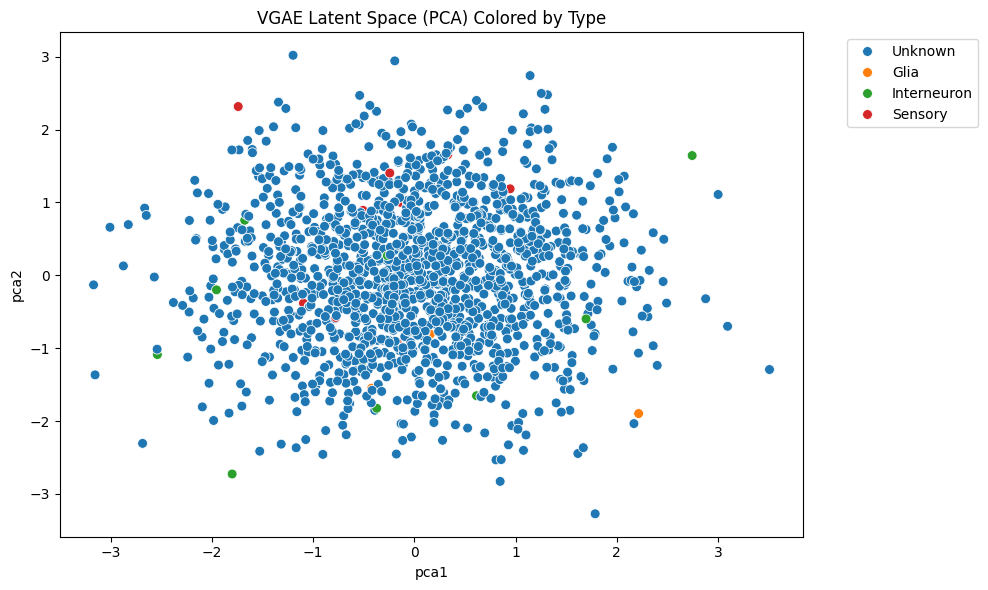

In [47]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
df_latent[["pca1", "pca2"]] = pca.fit_transform(df_latent.filter(like="z_"))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_latent, x="pca1", y="pca2", hue="Type", palette="tab10", s=50)
plt.title("VGAE Latent Space (PCA) Colored by Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


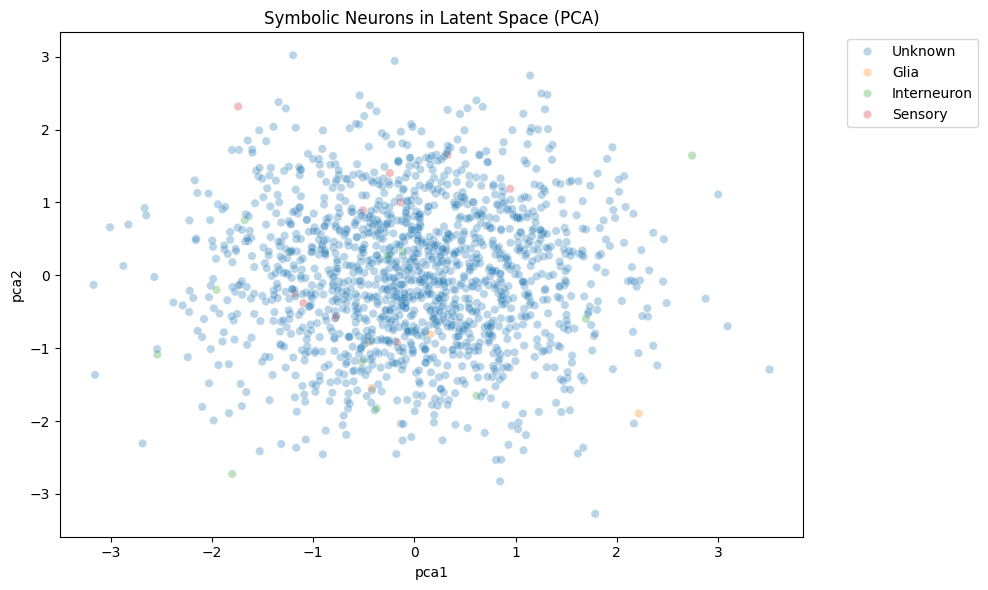

In [48]:
symbolic_roles = ["Apollo", "Zeus", "Hephaestus"]
df_symbolic = df_latent[df_latent["SymbolicRole"].isin(symbolic_roles)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_latent, x="pca1", y="pca2", hue="Type", alpha=0.3)
sns.scatterplot(data=df_symbolic, x="pca1", y="pca2", hue="SymbolicRole", s=100, marker="X", palette="Set2")
plt.title("Symbolic Neurons in Latent Space (PCA)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [49]:
from sklearn.metrics.pairwise import cosine_similarity

def find_nearest_neighbors(df_latent, neuron_name, top_k=5):
    z_cols = [col for col in df_latent.columns if col.startswith("z_")]
    query_vec = df_latent.loc[neuron_name, z_cols].values.reshape(1, -1)
    sims = cosine_similarity(df_latent[z_cols], query_vec).flatten()
    df_latent["cosine_sim"] = sims
    return df_latent.drop(index=neuron_name).sort_values("cosine_sim", ascending=False).head(top_k)

for neuron in df_symbolic.index:
    print(f"\n🔎 Nearest neighbors to {neuron} ({df_latent.loc[neuron, 'SymbolicRole']}):")
    display(find_nearest_neighbors(df_latent, neuron)[["Type", "SymbolicRole", "cosine_sim"]])
